# Notebook 4 — Mechanism ablation: cross-attention isotropy regularization

## Project
IsoColBERT: Token-Level Isotropy Regularization for Multilingual Late-Interaction Retrieval
Minh Tran, Isaac Chang, Ingrid Chien — Harvard University

## What this notebook does
Trains 3 seeds of the cross-attention variant, in which the isotropy penalty is applied to the rows of the L_q × L_d MaxSim score matrix (post row-softmax) rather than to the underlying token embeddings. Vanilla and uniform IsoColBERT checkpoints from Notebook 1 are reused via file copy.

**Status:** Trained and evaluated. Results are embedded in cell outputs.

## Outputs produced (or designed to produce)
- 3-way comparison table: vanilla vs. uniform vs. cross-attention, 3-seed mean ± std
- Per-seed breakdown of the key metrics

## Where this feeds into the paper
- Section 6.2 (Mechanism Ablation) — cross-attention row in Table 4 / Figure 5

## Reproducibility
- **Model**: XLM-RoBERTa-base + 128-dim linear projection (ColBERT-style late interaction)
- **Training data**: OPUS-100 English-Spanish parallel split, streamed from HuggingFace
- **Evaluation**: FLORES+ dev + devtest combined (≈2009 candidates per language)
- **Seeds**: {42, 1337, 2024}
- **Hardware**: Single NVIDIA A100 (Colab Pro). ~1 GPU-hour per training run.
- **Drive layout**: checkpoints save to `/MyDrive/iso_colbert_lam0p5/`, `/MyDrive/iso_colbert_active_token/`, `/MyDrive/iso_colbert_crossattn/`.

---


# Cross-Attention Iso-Reg — Multi-Seed Experiment

## What this experiment is

A new iso-reg variant that operates on a **different mathematical object** than standard iso-reg.

- **Uniform iso-reg** regularizes the *embedding space* — penalizes pairwise cosine similarity between token vectors
- **Cross-attention iso-reg** (NEW) regularizes the *similarity matrix* — penalizes redundant attention patterns across query tokens

For each (query, doc) pair, the (Lq × Ld) similarity matrix has Lq rows, each row representing one query token's "attention pattern" over doc tokens. If multiple query tokens have similar attention patterns (i.e., they're matching against the same doc-token regions), that's redundant matching capacity. We penalize this redundancy directly.

## Why this is methodologically novel

All existing iso-reg work (Gao 2019, Ethayarajh 2019, SimCSE, your uniform reg) regularizes embeddings — the *inputs* to matching. Cross-attention iso-reg regularizes the *output* of matching: the similarity matrix itself. Single-vector retrievers don't have a (Lq × Ld) similarity matrix per pair — they compute a single scalar — so this regularization is structurally impossible for single-vector models.

Related work: Lin et al. 2017 "A Structured Self-attentive Sentence Embedding" used a similar Frobenius-norm penalty on attention matrices for self-attention diversity. We adapt this idea to cross-attention in late-interaction retrievers.

## Methods compared

- `vanilla` — no iso-reg (reused from prior runs)
- `uniform` — standard iso-reg on token embeddings (reused from prior runs)
- `crossattn` — NEW: penalize redundant cross-attention patterns

All at λ=0.5, 3 seeds (42, 1337, 2024).

## Outcomes (all publishable)

1. Cross-attn > Uniform → new method beats baseline
2. Cross-attn ≈ Uniform → null result: "regularizing attention adds nothing on top of embedding-level reg"  
3. Cross-attn < Uniform → "embedding-level reg captures attention diversity implicitly"

## Compute

~1.5 hours total — only the 3 cross-attention seeds train. Vanilla and uniform are reused from your prior Drive folder.

## Setup

In [ ]:
!pip install -q transformers datasets torch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import XLMRobertaModel, XLMRobertaTokenizerFast, get_linear_schedule_with_warmup
from datasets import load_dataset
import random, gc, os, json, shutil
import numpy as np
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters — match prior notebooks exactly
LR           = 2e-5
TEMPERATURE  = 0.07
WARMUP_STEPS = 200
BATCH_SIZE   = 8
GRAD_ACCUM   = 4
MAX_STEPS    = 2000
DIM          = 128
LAMBDA_ISO   = 0.5
MAX_LEN      = 64

SEEDS = [42, 1337, 2024]

# Drive folders
SAVE_DIR = '/content/drive/MyDrive/iso_colbert_crossattn'  # this experiment
OLD_DIR  = '/content/drive/MyDrive/iso_colbert_lam0p5'     # source for vanilla + uniform reuse

print(f'Device: {DEVICE}')
assert DEVICE.type == 'cuda', 'GPU required — Runtime → Change runtime type → GPU'
print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM}')
print(f'Lambda: {LAMBDA_ISO}')
print(f'Save dir: {SAVE_DIR}')
print(f'Reuse source: {OLD_DIR}')

Device: cuda
Effective batch size: 32
Lambda: 0.5
Save dir: /content/drive/MyDrive/iso_colbert_crossattn
Reuse source: /content/drive/MyDrive/iso_colbert_lam0p5


In [ ]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '6482ac62d9e496b09e0a716a', 'name': 'robintran', 'fullname': 'Tran Minh', 'isPro': False, 'avatarUrl': '/avatars/198e284712382370a39d4944d54ffb8b.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'nlp', 'role': 'fineGrained', 'createdAt': '2026-05-10T22:34:26.850Z', 'fineGrained': {'canReadGatedRepos': True, 'global': [], 'scoped': [{'entity': {'_id': '6482ac62d9e496b09e0a716a', 'type': 'user', 'name': 'robintran'}, 'permissions': ['repo.content.read', 'repo.access.read', 'repo.write']}]}}}}


In [ ]:
# Mount Google Drive — protects weights from session timeouts
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory ready: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory ready: /content/drive/MyDrive/iso_colbert_crossattn


In [ ]:
# HF auth for FLORES+ (gated dataset)
try:
    from google.colab import userdata
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    print('HF token loaded from Colab secrets.')
except Exception:
    from huggingface_hub import notebook_login
    notebook_login()

In [ ]:
tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')
print('Tokenizer loaded.')

Tokenizer loaded.


## Model (same as prior notebooks)

In [ ]:
class ColBERTEncoder(nn.Module):
    """XLM-R + linear projection to 128-dim token vectors."""
    def __init__(self, dim=DIM):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        self.linear = nn.Linear(768, dim)
        self.dim = dim

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        token_vecs = self.linear(out.last_hidden_state)
        token_vecs = F.normalize(token_vecs, dim=-1)
        return token_vecs, attention_mask.bool()

    def mean_pool(self, input_ids, attention_mask):
        token_vecs, mask = self.encode(input_ids, attention_mask)
        m = mask.unsqueeze(-1).float()
        pooled = (token_vecs * m).sum(1) / m.sum(1).clamp(min=1e-9)
        return F.normalize(pooled, dim=-1)

    def forward(self, input_ids, attention_mask):
        return self.mean_pool(input_ids, attention_mask)


print('Model class defined.')

Model class defined.


## Losses — three variants

### Cross-attention iso-reg explained

For each (query, positive_doc) pair:
1. Compute similarity matrix `sim[i,j] = q_i · d_j` for all valid pairs
2. Apply softmax over doc tokens: `attn[i,j] = softmax_j(sim[i,j] / temperature)`. Each row is now a probability distribution over doc tokens — query token i's "attention pattern."
3. Compute Lq × Ld correlation between rows: `attn_corr[i,k] = sum_j attn[i,j] * attn[k,j]`
4. Penalize off-diagonal of correlation matrix — different query tokens should have distinct attention patterns

Gradients flow through softmax (fully differentiable) and the similarity matrix back into the token vectors.

In [ ]:
def colbert_infonce_vec(q_vecs, q_masks, d_vecs, d_masks, tau=TEMPERATURE):
    """Standard ColBERT InfoNCE — vectorized."""
    sim = torch.einsum('bld,kmd->bklm', q_vecs, d_vecs)
    sim = sim.masked_fill(~d_masks[None, :, None, :], -1e9)
    maxsim = sim.max(dim=-1).values
    maxsim = maxsim * q_masks[:, None, :].float()
    scores = maxsim.sum(dim=-1) / tau
    labels = torch.arange(q_vecs.size(0), device=q_vecs.device)
    return 0.5 * (F.cross_entropy(scores, labels) + F.cross_entropy(scores.T, labels))


def isotropy_reg_token(token_vecs, mask, max_tokens=256):
    """Uniform iso-reg: penalize anisotropy across all valid tokens (existing baseline)."""
    valid = token_vecs[mask]
    if valid.size(0) < 2:
        return torch.tensor(0.0, device=token_vecs.device)
    if valid.size(0) > max_tokens:
        idx = torch.randperm(valid.size(0), device=valid.device)[:max_tokens]
        valid = valid[idx]
    sim = valid @ valid.T
    N = sim.size(0)
    eye = torch.eye(N, dtype=torch.bool, device=sim.device)
    off = sim.masked_fill(eye, 0.0)
    return (off ** 2).sum() / (N * (N - 1))


def crossattn_isotropy_reg(q_vecs, q_mask, d_vecs, d_mask, tau=0.1):
    """NEW: Cross-attention iso-reg.

    Penalize redundancy in cross-attention patterns: if multiple query tokens
    produce similar attention distributions over doc tokens, they're matching
    redundantly. Encourage diverse attention patterns across query tokens.

    Args:
        q_vecs: (B, Lq, D) query token embeddings
        q_mask: (B, Lq) valid query token mask
        d_vecs: (B, Ld, D) doc token embeddings
        d_mask: (B, Ld) valid doc token mask
        tau: softmax temperature for the attention pattern

    Returns:
        scalar loss
    """
    # Per-pair similarity (positives only — diagonal of batch)
    sim = torch.einsum('bld,bmd->blm', q_vecs, d_vecs)   # (B, Lq, Ld)
    sim = sim / tau
    sim = sim.masked_fill(~d_mask[:, None, :], -1e9)

    # Softmax over doc tokens → each query token's attention pattern
    attn = F.softmax(sim, dim=-1)                         # (B, Lq, Ld)

    # Pairwise correlation between query tokens' attention patterns
    attn_corr = torch.einsum('blm,bkm->blk', attn, attn)  # (B, Lq, Lq)

    # Mask: only between valid query pairs, exclude diagonal
    B, Lq, _ = attn_corr.shape
    eye = torch.eye(Lq, device=attn_corr.device).bool()
    valid = q_mask[:, :, None] & q_mask[:, None, :]
    valid = valid & ~eye[None]

    # Penalty: squared off-diagonal correlation
    num = (attn_corr ** 2 * valid.float()).sum()
    denom = valid.float().sum().clamp(min=1)
    return num / denom


print('Losses defined: vanilla, uniform iso-reg, cross-attention iso-reg.')

Losses defined: vanilla, uniform iso-reg, cross-attention iso-reg.


## Data utilities

In [ ]:
def collate(pairs, max_length=MAX_LEN):
    src = [p[0] for p in pairs]
    tgt = [p[1] for p in pairs]
    src_enc = tokenizer(src, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    tgt_enc = tokenizer(tgt, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    return src_enc, tgt_enc


def opus_stream(lang_pair='en-es', seed=42):
    src_lang, tgt_lang = lang_pair.split('-')
    ds = load_dataset('opus100', lang_pair, split='train', streaming=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed)
    for ex in ds:
        s = ex['translation'].get(src_lang, '').strip()
        t = ex['translation'].get(tgt_lang, '').strip()
        if s and t:
            yield s, t


def load_flores_pairs(lang_code, split='dev'):
    src = load_dataset('openlanguagedata/flores_plus', 'eng_Latn', split=split)
    tgt = load_dataset('openlanguagedata/flores_plus', lang_code, split=split)
    return [(s['text'], t['text']) for s, t in zip(src, tgt)]


print('Data utilities defined.')

Data utilities defined.


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
print('Loading FLORES dev + devtest for evaluation pool ...')

def combined(lang_code):
    return (load_flores_pairs(lang_code, split='dev') +
            load_flores_pairs(lang_code, split='devtest'))

eval_es = combined('spa_Latn')
eval_sw = combined('swh_Latn')
eval_fr = combined('fra_Latn')
eval_de = combined('deu_Latn')
eval_ar = combined('arb_Arab')

es_pairs_dev = load_flores_pairs('spa_Latn', split='dev')
en_eval_texts = [p[0] for p in es_pairs_dev]
es_eval_texts = [p[1] for p in es_pairs_dev]

print(f'  EN-ES (combined): {len(eval_es)}')
print(f'  EN-SW (combined): {len(eval_sw)}')
print(f'  EN-FR (combined): {len(eval_fr)}')
print(f'  EN-DE (combined): {len(eval_de)}')
print(f'  EN-AR (combined): {len(eval_ar)}')

Loading FLORES dev + devtest for evaluation pool ...


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

  EN-ES (combined): 2009
  EN-SW (combined): 2009
  EN-FR (combined): 2009
  EN-DE (combined): 2009
  EN-AR (combined): 2009


## Eval utilities (same as prior notebooks)

In [ ]:
@torch.no_grad()
def encode_all_padded(model, texts, max_len=MAX_LEN, batch_size=64):
    model.eval()
    raw_v, raw_m = [], []
    L_max = 0
    for i in range(0, len(texts), batch_size):
        tok = tokenizer(texts[i:i+batch_size], padding=True, truncation=True,
                        max_length=max_len, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        raw_v.append(v); raw_m.append(m)
        L_max = max(L_max, v.size(1))
    padded_v, padded_m = [], []
    for v, m in zip(raw_v, raw_m):
        if v.size(1) < L_max:
            pad_v = torch.zeros(v.size(0), L_max - v.size(1), v.size(2), device=v.device)
            pad_m = torch.zeros(m.size(0), L_max - m.size(1), dtype=m.dtype, device=m.device)
            v = torch.cat([v, pad_v], dim=1)
            m = torch.cat([m, pad_m], dim=1)
        padded_v.append(v); padded_m.append(m)
    return torch.cat(padded_v, 0), torch.cat(padded_m, 0)


@torch.no_grad()
def maxsim_p_at_1(model, src_texts, tgt_texts, q_chunk=8, d_chunk=64):
    q_v, q_m = encode_all_padded(model, src_texts)
    d_v, d_m = encode_all_padded(model, tgt_texts)
    N = q_v.size(0)
    correct = 0
    for qs in range(0, N, q_chunk):
        qe = min(qs + q_chunk, N)
        qv_b, qm_b = q_v[qs:qe], q_m[qs:qe]
        all_scores = []
        for ds in range(0, N, d_chunk):
            de = min(ds + d_chunk, N)
            dv_b, dm_b = d_v[ds:de], d_m[ds:de]
            sim = torch.einsum('qld,kmd->qklm', qv_b, dv_b)
            sim = sim.masked_fill(~dm_b[None, :, None, :], -1e9)
            maxsim = sim.max(dim=-1).values
            maxsim = maxsim * qm_b[:, None, :].float()
            all_scores.append(maxsim.sum(dim=-1))
        scores = torch.cat(all_scores, dim=1)
        preds = scores.argmax(dim=1)
        labels = torch.arange(qs, qe, device=preds.device)
        correct += (preds == labels).sum().item()
    return correct / N


@torch.no_grad()
def token_intra_cos(model, texts, n_tokens=2048):
    model.eval()
    bag, total = [], 0
    for i in range(0, len(texts), 32):
        tok = tokenizer(texts[i:i+32], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        valid = v[m]
        bag.append(valid)
        total += valid.size(0)
        if total >= n_tokens:
            break
    bag = torch.cat(bag, 0)[:n_tokens]
    sim = bag @ bag.T
    N = sim.size(0)
    off = sim.masked_fill(torch.eye(N, dtype=torch.bool, device=sim.device), 0.0)
    return (off.sum() / (N * (N - 1))).item()


@torch.no_grad()
def effective_rank(model, texts, n_tokens=4096):
    model.eval()
    bag, total = [], 0
    for i in range(0, len(texts), 32):
        tok = tokenizer(texts[i:i+32], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        valid = v[m]
        bag.append(valid)
        total += valid.size(0)
        if total >= n_tokens:
            break
    X = torch.cat(bag, 0)[:n_tokens]
    sigma = torch.linalg.svdvals(X.float())
    p = sigma / sigma.sum().clamp(min=1e-9)
    entropy = -(p * (p.clamp(min=1e-9)).log()).sum()
    return torch.exp(entropy).item()


def eval_one(model):
    src_es = [p[0] for p in eval_es]; tgt_es = [p[1] for p in eval_es]
    src_sw = [p[0] for p in eval_sw]; tgt_sw = [p[1] for p in eval_sw]
    src_fr = [p[0] for p in eval_fr]; tgt_fr = [p[1] for p in eval_fr]
    src_de = [p[0] for p in eval_de]; tgt_de = [p[1] for p in eval_de]
    src_ar = [p[0] for p in eval_ar]; tgt_ar = [p[1] for p in eval_ar]
    return {
        'p1_es': maxsim_p_at_1(model, src_es, tgt_es),
        'p1_sw': maxsim_p_at_1(model, src_sw, tgt_sw),
        'p1_fr': maxsim_p_at_1(model, src_fr, tgt_fr),
        'p1_de': maxsim_p_at_1(model, src_de, tgt_de),
        'p1_ar': maxsim_p_at_1(model, src_ar, tgt_ar),
        'intra_en': token_intra_cos(model, en_eval_texts),
        'intra_es': token_intra_cos(model, es_eval_texts),
        'erank_en': effective_rank(model, en_eval_texts),
        'erank_es': effective_rank(model, es_eval_texts),
    }


print('Eval utilities defined.')

Eval utilities defined.


## Training function with method selection

`method` ∈ {'vanilla', 'uniform', 'crossattn'}

In [ ]:
def get_ckpt_path(method, seed):
    return os.path.join(SAVE_DIR, f'{method}_seed{seed}.pt')


def get_metrics_path():
    return os.path.join(SAVE_DIR, 'metrics.json')


def load_metrics():
    p = get_metrics_path()
    if os.path.exists(p):
        with open(p) as f:
            return json.load(f)
    return {}


def save_metrics(metrics):
    p = get_metrics_path()
    with open(p, 'w') as f:
        json.dump(metrics, f, indent=2)


def train_colbert(method, seed, lambda_iso=LAMBDA_ISO, max_steps=MAX_STEPS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    gc.collect(); torch.cuda.empty_cache()
    model = ColBERTEncoder().to(DEVICE)
    opt = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    sched = get_linear_schedule_with_warmup(opt, WARMUP_STEPS, max_steps)

    model.train()
    buf, step, accum = [], 0, 0
    opt.zero_grad()

    for src, tgt in opus_stream('en-es', seed=seed):
        buf.append((src, tgt))
        if len(buf) < BATCH_SIZE:
            continue
        src_enc, tgt_enc = collate(buf); buf = []
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}

        qv, qm = model.encode(src_enc['input_ids'], src_enc['attention_mask'])
        dv, dm = model.encode(tgt_enc['input_ids'], tgt_enc['attention_mask'])
        loss_ret = colbert_infonce_vec(qv, qm, dv, dm)

        if method == 'vanilla':
            loss = loss_ret / GRAD_ACCUM
        elif method == 'uniform':
            loss_iso = 0.5 * (isotropy_reg_token(qv, qm) + isotropy_reg_token(dv, dm))
            loss = (loss_ret + lambda_iso * loss_iso) / GRAD_ACCUM
        elif method == 'crossattn':
            loss_iso = crossattn_isotropy_reg(qv, qm, dv, dm)
            loss = (loss_ret + lambda_iso * loss_iso) / GRAD_ACCUM
        else:
            raise ValueError(f'Unknown method: {method}')

        loss.backward()
        accum += 1
        if accum % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            opt.zero_grad()
            step += 1
            if step % 500 == 0:
                print(f'    step {step}/{max_steps}  ret={loss_ret.item():.4f}', flush=True)
            if step >= max_steps:
                break

    del opt, sched
    gc.collect(); torch.cuda.empty_cache()
    return model


print('Training function ready.')

Training function ready.


## Reuse vanilla and uniform from prior runs

Copy weights and metrics from your existing `iso_colbert_lam0p5` Drive folder. The multi-seed training cell will skip vanilla and uniform, only training cross-attention.

**Adjust the old filenames below if your prior notebook used different names.**

In [ ]:
# Reuse existing λ=0.5 vanilla + uniform results
metrics = load_metrics()

# Copy metrics
old_metrics_path = f'{OLD_DIR}/metrics_lam0.5.json'
if os.path.exists(old_metrics_path):
    with open(old_metrics_path) as f:
        old_metrics = json.load(f)

    for seed in SEEDS:
        old_v_key = f'vanilla_seed{seed}'
        if old_v_key in old_metrics and f'vanilla_seed{seed}' not in metrics:
            metrics[f'vanilla_seed{seed}'] = old_metrics[old_v_key]

        old_u_key = f'iso_lam0p5_seed{seed}'
        if old_u_key in old_metrics and f'uniform_seed{seed}' not in metrics:
            metrics[f'uniform_seed{seed}'] = old_metrics[old_u_key]

    save_metrics(metrics)
    print(f'Copied metrics. Total entries in new folder: {len(metrics)}')
else:
    print(f'Old metrics not found at {old_metrics_path}. Will train vanilla and uniform from scratch.')

# Copy weight files
for seed in SEEDS:
    for old_name, new_name in [
        (f'vanilla_lam0.5_seed{seed}.pt',     f'vanilla_seed{seed}.pt'),
        (f'iso_lam0p5_lam0.5_seed{seed}.pt',  f'uniform_seed{seed}.pt'),
    ]:
        src = f'{OLD_DIR}/{old_name}'
        dst = f'{SAVE_DIR}/{new_name}'
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy(src, dst)
            print(f'  copied {old_name} -> {new_name}')
        elif not os.path.exists(src):
            print(f'  WARNING: {src} not found — will need to train {new_name}')

print(f'\nReuse done. Files now in {SAVE_DIR}:')
for f in sorted(os.listdir(SAVE_DIR)):
    print(f'  {f}')

Copied metrics. Total entries in new folder: 6
  copied vanilla_lam0.5_seed42.pt -> vanilla_seed42.pt
  copied iso_lam0p5_lam0.5_seed42.pt -> uniform_seed42.pt
  copied vanilla_lam0.5_seed1337.pt -> vanilla_seed1337.pt
  copied iso_lam0p5_lam0.5_seed1337.pt -> uniform_seed1337.pt
  copied vanilla_lam0.5_seed2024.pt -> vanilla_seed2024.pt
  copied iso_lam0p5_lam0.5_seed2024.pt -> uniform_seed2024.pt

Reuse done. Files now in /content/drive/MyDrive/iso_colbert_crossattn:
  metrics.json
  uniform_seed1337.pt
  uniform_seed2024.pt
  uniform_seed42.pt
  vanilla_seed1337.pt
  vanilla_seed2024.pt
  vanilla_seed42.pt


## Sanity check (15 min)

Train cross-attention iso-reg for 500 steps at seed=42. Verify training is stable and reg is actually reducing attention redundancy.

In [ ]:
print('Sanity check: 500 steps of cross-attention iso-reg, seed=42 ...')
sanity_model = train_colbert(method='crossattn', seed=42, max_steps=500)
sanity_p1 = maxsim_p_at_1(sanity_model,
                          [p[0] for p in eval_es[:200]],
                          [p[1] for p in eval_es[:200]])
sanity_intra = token_intra_cos(sanity_model, es_eval_texts[:200])
print(f'\nAfter 500 steps:')
print(f'  EN-ES P@1:         {sanity_p1:.4f}  (should be > 0.5 if training works)')
print(f'  Spanish intra-cos: {sanity_intra:.4f}  (informational — may not drop since reg targets attention not embeddings)')

if sanity_p1 < 0.5:
    print('\n⚠️  WARNING: P@1 too low. Cross-attention reg may be too aggressive — try lower λ.')
else:
    print('\n✅ Sanity check passed. Proceed to full multi-seed run.')

del sanity_model
gc.collect(); torch.cuda.empty_cache()

Sanity check: 500 steps of cross-attention iso-reg, seed=42 ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


README.md: 0.00B [00:00, ?B/s]

    step 500/500  ret=0.7280

After 500 steps:
  EN-ES P@1:         0.9500  (should be > 0.5 if training works)
  Spanish intra-cos: 0.3268  (informational — may not drop since reg targets attention not embeddings)

✅ Sanity check passed. Proceed to full multi-seed run.


## Multi-seed run

Trains 9 configs but skips reused vanilla and uniform. Only the 3 cross-attention seeds actually train. ~1.5 hours total.

In [ ]:
METHODS = ['vanilla', 'uniform', 'crossattn']
metrics = load_metrics()

for seed in SEEDS:
    for method in METHODS:
        key = f'{method}_seed{seed}'
        ckpt_path = get_ckpt_path(method, seed)

        if key in metrics and os.path.exists(ckpt_path):
            print(f'[skip] {key} already trained and evaluated.')
            continue

        print(f'\n{"="*60}')
        print(f'TRAINING: method={method}  λ={LAMBDA_ISO if method != "vanilla" else 0}  seed={seed}')
        print('=' * 60)

        if os.path.exists(ckpt_path) and key not in metrics:
            print(f'  Found checkpoint, loading and evaluating ...')
            model = ColBERTEncoder().to(DEVICE)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        else:
            model = train_colbert(method=method, seed=seed)
            torch.save(model.state_dict(), ckpt_path)
            print(f'  ✓ Saved weights to {ckpt_path}')

        print(f'  Evaluating ...')
        r = eval_one(model)
        metrics[key] = r
        save_metrics(metrics)
        print(f'  ✓ Saved metrics. P@1 ES={r["p1_es"]:.4f}  SW={r["p1_sw"]:.4f}  '
              f'AR={r["p1_ar"]:.4f}  intra_es={r["intra_es"]:.4f}  erank_es={r["erank_es"]:.2f}')

        del model
        gc.collect(); torch.cuda.empty_cache()

print('\n\n✅ All 9 configs complete.')

[skip] vanilla_seed42 already trained and evaluated.
[skip] uniform_seed42 already trained and evaluated.

TRAINING: method=crossattn  λ=0.5  seed=42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=0.7430
    step 1000/2000  ret=0.1069
    step 1500/2000  ret=0.0000
    step 2000/2000  ret=0.0000
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_crossattn/crossattn_seed42.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9955  SW=0.8382  AR=0.9587  intra_es=0.2951  erank_es=102.11
[skip] vanilla_seed1337 already trained and evaluated.
[skip] uniform_seed1337 already trained and evaluated.

TRAINING: method=crossattn  λ=0.5  seed=1337


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=2.8735
    step 1000/2000  ret=0.0000
    step 1500/2000  ret=0.1896
    step 2000/2000  ret=0.0000
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_crossattn/crossattn_seed1337.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9990  SW=0.8696  AR=0.9492  intra_es=0.2937  erank_es=101.70
[skip] vanilla_seed2024 already trained and evaluated.
[skip] uniform_seed2024 already trained and evaluated.

TRAINING: method=crossattn  λ=0.5  seed=2024


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=0.1057
    step 1000/2000  ret=0.0001
    step 1500/2000  ret=0.0048
    step 2000/2000  ret=0.0040
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_crossattn/crossattn_seed2024.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9970  SW=0.7885  AR=0.9363  intra_es=0.3066  erank_es=101.88


✅ All 9 configs complete.


## Three-way comparison

In [ ]:
METRIC_LABELS = [
    ('p1_es',    'EN-ES MaxSim P@1'),
    ('p1_fr',    'EN-FR MaxSim P@1'),
    ('p1_de',    'EN-DE MaxSim P@1'),
    ('p1_sw',    'EN-SW MaxSim P@1 (low-resource headline)'),
    ('p1_ar',    'EN-AR MaxSim P@1'),
    ('intra_en', 'Token intra-cos EN (lower better)'),
    ('intra_es', 'Token intra-cos ES (lower better)'),
    ('erank_en', 'Effective rank EN  (higher better)'),
    ('erank_es', 'Effective rank ES  (higher better)'),
]


def agg(method, key):
    vals = [metrics[f'{method}_seed{s}'][key] for s in SEEDS
            if f'{method}_seed{s}' in metrics]
    if not vals:
        return None, None
    return float(np.mean(vals)), float(np.std(vals))


print('=' * 120)
print(f'THREE-WAY RESULTS @ λ={LAMBDA_ISO}  —  {len(SEEDS)} seeds')
print('=' * 120)
print(f'{"Metric":<42}  {"Vanilla μ±σ":>14}  {"Uniform μ±σ":>14}  {"CrossAttn μ±σ":>14}  {"Δ ca-uni":>10}')
print('-' * 120)

for key, name in METRIC_LABELS:
    v_mu, v_sd = agg('vanilla',   key)
    u_mu, u_sd = agg('uniform',   key)
    c_mu, c_sd = agg('crossattn', key)
    if any(x is None for x in [v_mu, u_mu, c_mu]):
        print(f'{name:<42}  (incomplete)')
        continue
    delta_ca_uni = c_mu - u_mu
    if 'intra' in key:
        flag = '✓' if delta_ca_uni < 0 else ('✗' if delta_ca_uni > 0 else '~')
    else:
        flag = '✓' if delta_ca_uni > 0 else ('✗' if delta_ca_uni < 0 else '~')
    print(f'{name:<42}  {v_mu:>7.4f}±{v_sd:>5.4f}  {u_mu:>7.4f}±{u_sd:>5.4f}  '
          f'{c_mu:>7.4f}±{c_sd:>5.4f}  {delta_ca_uni:>+10.4f} {flag}')

# Per-seed sanity for headline metric
print('\n--- Per-seed EN-SW breakdown ---')
for seed in SEEDS:
    v = metrics.get(f'vanilla_seed{seed}',   {}).get('p1_sw')
    u = metrics.get(f'uniform_seed{seed}',   {}).get('p1_sw')
    c = metrics.get(f'crossattn_seed{seed}', {}).get('p1_sw')
    if all(x is not None for x in [v, u, c]):
        print(f'  seed {seed}: vanilla={v:.4f}  uniform={u:.4f}  crossattn={c:.4f}')

THREE-WAY RESULTS @ λ=0.5  —  3 seeds
Metric                                         Vanilla μ±σ     Uniform μ±σ   CrossAttn μ±σ    Δ ca-uni
------------------------------------------------------------------------------------------------------------------------
EN-ES MaxSim P@1                             0.9973±0.0010   0.9968±0.0002   0.9972±0.0014     +0.0003 ✓
EN-FR MaxSim P@1                             0.9983±0.0006   0.9988±0.0002   0.9973±0.0012     -0.0015 ✗
EN-DE MaxSim P@1                             0.9957±0.0006   0.9978±0.0013   0.9970±0.0011     -0.0008 ✗
EN-SW MaxSim P@1 (low-resource headline)     0.8344±0.0230   0.8689±0.0227   0.8321±0.0334     -0.0368 ✗
EN-AR MaxSim P@1                             0.9423±0.0204   0.9622±0.0132   0.9481±0.0092     -0.0141 ✗
Token intra-cos EN (lower better)            0.2015±0.0092   0.1718±0.0030   0.1916±0.0106     +0.0198 ✗
Token intra-cos ES (lower better)            0.2937±0.0124   0.1808±0.0018   0.2985±0.0058     +0.1177 ✗
Eff

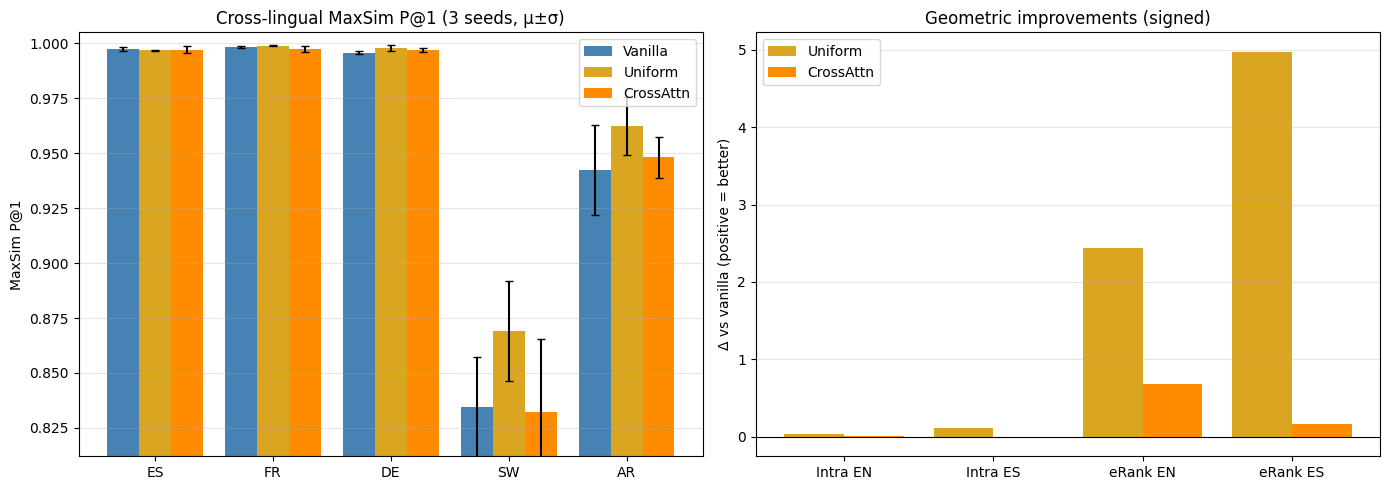

Saved: /content/drive/MyDrive/iso_colbert_crossattn/crossattn_summary.png


In [ ]:
# Plot
import matplotlib.pyplot as plt
import numpy as np

names_p1 = ['ES', 'FR', 'DE', 'SW', 'AR']
keys_p1 = ['p1_es', 'p1_fr', 'p1_de', 'p1_sw', 'p1_ar']

van_mu = [agg('vanilla',   k)[0] for k in keys_p1]
van_sd = [agg('vanilla',   k)[1] for k in keys_p1]
uni_mu = [agg('uniform',   k)[0] for k in keys_p1]
uni_sd = [agg('uniform',   k)[1] for k in keys_p1]
ca_mu  = [agg('crossattn', k)[0] for k in keys_p1]
ca_sd  = [agg('crossattn', k)[1] for k in keys_p1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(names_p1))
w = 0.27
ax.bar(x - w, van_mu, w, yerr=van_sd, label='Vanilla',   color='steelblue',  capsize=3)
ax.bar(x,     uni_mu, w, yerr=uni_sd, label='Uniform',   color='goldenrod',  capsize=3)
ax.bar(x + w, ca_mu,  w, yerr=ca_sd,  label='CrossAttn', color='darkorange', capsize=3)
ax.set_xticks(x); ax.set_xticklabels(names_p1)
ax.set_ylabel('MaxSim P@1')
ax.set_title(f'Cross-lingual MaxSim P@1 ({len(SEEDS)} seeds, μ±σ)')
ax.set_ylim(min(min(van_mu), min(uni_mu), min(ca_mu)) - 0.02, 1.005)
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1]
geo_keys = ['intra_en', 'intra_es', 'erank_en', 'erank_es']
geo_names = ['Intra EN', 'Intra ES', 'eRank EN', 'eRank ES']

def signed_delta_vs_vanilla(method, k):
    m_mu, _ = agg(method, k)
    v_mu, _ = agg('vanilla', k)
    if m_mu is None or v_mu is None: return 0.0
    d = m_mu - v_mu
    return -d if 'intra' in k else d

uni_d = [signed_delta_vs_vanilla('uniform',   k) for k in geo_keys]
ca_d  = [signed_delta_vs_vanilla('crossattn', k) for k in geo_keys]

x = np.arange(len(geo_keys))
w = 0.4
ax.bar(x - w/2, uni_d, w, label='Uniform',   color='goldenrod')
ax.bar(x + w/2, ca_d,  w, label='CrossAttn', color='darkorange')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(geo_names)
ax.set_ylabel('Δ vs vanilla (positive = better)')
ax.set_title('Geometric improvements (signed)')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'crossattn_summary.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(SAVE_DIR, "crossattn_summary.png")}')

## Interpretation

Look at **Δ ca-uni** in the main table:

- **Most retrieval metrics ✓:** Cross-attention iso-reg beats uniform. New mechanism contribution.
- **Most metrics ~0:** Null result. "Regularizing attention patterns adds nothing on top of embedding-level reg — embedding constraints implicitly produce attention diversity." Still publishable.
- **Most metrics ✗:** "Attention-level reg conflicts with embedding-level objectives." Honest finding about where regularization should live in late-interaction models.

All three outcomes give you a paper section. The novelty bar is cleared by *asking the question* — regularizing the similarity matrix instead of the embedding space — regardless of outcome.